# Differential Growth — 2D Implementation

**Ali Chaaraoui & Jay Anupoju**


The pattern comes from two things:

- **Adaptive subdivision** continuously inserts new nodes, adding length to the curve.
- **Repulsion** prevents any two nodes from occupying the same space.

Attraction, alignment and Brownian motion shape what the folds look like, but subdivision and
repulsion are what make it grow at all.

### Relationship to Dr. Ferdousi's implementation

Built from her working `Differential Growth.ipynb`, following her structure: her `Particle` class,
her function names (`splitEdges`, `pruneNodes`, `applyRepulsion`, `applyAttraction`,
`applyAlignment`, `applyBrownianMotion`, `getConnectedNode`, `getMidpointNode`), her loop order,
and her parameter values unchanged.

Two things different:

1. **Constants live in one `params` dict** rather than inside the functions that use them, so
   rules can be switched on individually and parameters can be swept.
2. **Force functions return displacements** instead of moving nodes in place, so all forces can be
   summed against a single frozen snapshot and applied at once.

### Build stages

Rules are switched on one at a time via `params["weights"]`, so each figure isolates exactly what
one rule contributes. Every stage starts from identical initial conditions.

| Stage | Rules active |
|---|---|
| 1 | subdivision only |
| 2 | + repulsion |
| 3 | + attraction |
| 4 | + alignment |
| 5 | + Brownian motion |

### References

- [Jason Webb — *2D Differential Growth in JS*](https://medium.com/@jason.webb/2d-differential-growth-in-js-1843fd51b0ce) — attraction, repulsion, alignment, adaptive subdivision
- [Kaspar — *Differential Growth*](https://www.kaspar.wtf/blog/differential-growth) — the minimal subdivision + repulsion formulation

## 1 · Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2 · Parameters

Dr. Ferdousi's values, calibrated for a circle of radius 5.

Differential growth is **scale-invariant** — multiply all positions and all *length* parameters by
the same factor and the simulation is identical. So lengths are written as multiples of
`maxDistance`, which means this tuning transfers to any domain. The force strengths are
dimensionless fractions and do not scale.

A weight of `0.0` disables that rule.

In [ ]:
maxDistance = 1.0        # subdivision threshold — every other length keys off this

params = {
    # --- initial path ---
    "n_initial":       4,                     # Dr. Ferdousi's recommended starting count
    "circle_radius":   5.0,

    # --- lengths, as multiples of maxDistance ---
    "maxDistance":     maxDistance,           # split an edge longer than this
    "minDistance":     0.5  * maxDistance,    # remove a node closer than this
    "repulsionRadius": 2.0  * maxDistance,    # repel from nodes within this
    "brownianRange":   0.15 * maxDistance,    # jitter magnitude

    # --- force strengths (dimensionless) ---
    "repulsionForce":  0.05,
    "attractionForce": 0.05,
    "alignmentForce":  0.01,

    # --- run ---
    "n_iterations":    10,

    # --- which rules are active ---
    "weights": {
        "repulsion":  0.0,
        "attraction": 0.0,
        "alignment":  0.0,
        "brownian":   0.0,
    },
}

params

{'n_initial': 4,
 'circle_radius': 5.0,
 'maxDistance': 1.0,
 'minDistance': 0.5,
 'repulsionRadius': 2.0,
 'brownianRange': 0.15,
 'repulsionForce': 0.05,
 'attractionForce': 0.05,
 'alignmentForce': 0.01,
 'n_iterations': 10,
 'weights': {'repulsion': 0.0,
  'attraction': 0.0,
  'alignment': 0.0,
  'brownian': 0.0}}

## 3 · Step 1 — Create node

> *"Every node has at least one neighbour (two for closed line)."*

Differential growth runs on an **ordered closed loop**: node `i`'s neighbours are `i-1` and `i+1`,
wrapping at the ends. That ordering is the data structure — shuffle the list and you have the same
points but a different curve.

Four evenly spaced points on a circle gives a square: a genuine closed loop, small enough to check
by counting nodes.

`as_array` is the bridge between the two representations — particles hold the state, forces work
on an `(N, 2)` array so they can act on every node at once.

In [ ]:
class Particle:
    def __init__(self, _id, _pos_x, _pos_y):
        self.id = _id
        self.pos_x = _pos_x
        self.pos_y = _pos_y

    def __str__(self):
        return "{%d, %.3f, %.3f}" % (self.id, self.pos_x, self.pos_y)

    def get_position(self):
        return self.pos_x, self.pos_y


def circular_point(radius, theta):
    """A point on the circle at a given angle."""
    return radius * np.cos(theta), radius * np.sin(theta)


def create_n_particles_circular(n_particles, circle_radius):
    """n evenly spaced particles around the circle, in order."""
    thetas = np.linspace(0, 2 * np.pi, n_particles, endpoint=False)
    return [Particle(i, *circular_point(circle_radius, t))
            for i, t in enumerate(thetas)]


def getConnectedNode(index, particles):
    """Previous and next node indices, wrapping around the closed loop."""
    n = len(particles)
    return (index - 1) % n, (index + 1) % n


def as_array(particles):
    """Positions as an (N, 2) array — what the force functions operate on."""
    return np.array([[p.pos_x, p.pos_y] for p in particles])


def edge_lengths(particles):
    """Length of every edge at once. np.roll shifts the array by one row, so
    subtracting gives every edge vector and the wraparound handles itself."""
    pts = as_array(particles)
    return np.linalg.norm(np.roll(pts, -1, axis=0) - pts, axis=1)

In [ ]:
particles = create_n_particles_circular(params["n_initial"], params["circle_radius"])

for p in particles:
    print(" ", p)

pts = as_array(particles)
print("\ndistance from origin:", np.round(np.linalg.norm(pts, axis=1), 4))
print("edge lengths        :", np.round(edge_lengths(particles), 4))
print("expected            :", round(params["circle_radius"] * np.sqrt(2), 4),
      "(side of a square inscribed in a radius-5 circle)")
print("neighbours of node 0:", getConnectedNode(0, particles), "-> wraps back to node 3")

  {0, 5.000, 0.000}
  {1, 0.000, 5.000}
  {2, -5.000, 0.000}
  {3, -0.000, -5.000}

distance from origin: [5. 5. 5. 5.]
edge lengths        : [7.0711 7.0711 7.0711 7.0711]
expected            : 7.0711 (side of a square inscribed in a radius-5 circle)
neighbours of node 0: (3, 1) -> wraps back to node 3


## 4 · Step 2 — Adaptive subdivision

> *"If distance between two connected nodes becomes too big, add a node between them."*

**This is where the growth comes from.** Without it nothing new enters the system and the loop can
only move, never grow.

`pruneNodes` is the inverse, removing nodes that have crowded together. Without it node count only
ever climbs.

Both **return a new list** rather than modifying the one they were given. Walking a list while
inserting into it means the index no longer points where you think it does — that is the single
most common way this algorithm breaks. Because `splitEdges` appends the current node and *then*
the midpoint, the new node lands in the right place with no insertion index to calculate.

In [ ]:
def getMidpointNode(node1, node2):
    """Midpoint between two particles."""
    return (node1.pos_x + node2.pos_x) / 2.0, (node1.pos_y + node2.pos_y) / 2.0


def splitEdges(particles, params):
    """Insert a node in the middle of any edge longer than maxDistance."""
    lengths = edge_lengths(particles)
    out = []

    for i in range(len(particles)):
        out.append(particles[i])
        if lengths[i] >= params["maxDistance"]:
            _, next_i = getConnectedNode(i, particles)
            mx, my = getMidpointNode(particles[i], particles[next_i])
            out.append(Particle(-1, mx, my))

    for k, p in enumerate(out):
        p.id = k
    return out


def pruneNodes(particles, params):
    """Remove nodes that have drifted closer than minDistance to their neighbour."""
    if len(particles) <= 4:
        return particles

    minD = params["minDistance"]
    kept = [particles[0]]

    for i in range(1, len(particles)):
        dx = particles[i].pos_x - kept[-1].pos_x
        dy = particles[i].pos_y - kept[-1].pos_y
        if np.hypot(dx, dy) >= minD:
            kept.append(particles[i])

    # the closing edge wraps back to node 0 — check it too
    if len(kept) > 4:
        dx, dy = kept[-1].pos_x - kept[0].pos_x, kept[-1].pos_y - kept[0].pos_y
        if np.hypot(dx, dy) < minD:
            kept.pop()

    for k, p in enumerate(kept):
        p.id = k
    return kept

### Verifying subdivision by arithmetic

The starting square has sides of `5 × √2 ≈ 7.071`. `splitEdges` inserts at most one midpoint per
edge per pass, so each pass **doubles** the node count and **halves** the edge length:

| pass | nodes | edge |
|---|---|---|
| start | 4 | 7.071 |
| 1 | 8 | 3.536 |
| 2 | 16 | 1.768 |
| 3 | 32 | 0.884 |
| 4 | 32 | 0.884 — below threshold, stops |

Subdivision is correct if and only if the count goes **4 → 8 → 16 → 32** and then holds. No plot
needed.

In [ ]:
test = create_n_particles_circular(4, params["circle_radius"])
for i in range(5):
    test = pruneNodes(splitEdges(test, params), params)
    print(f"pass {i+1}: {len(test):3d} nodes, edge length {edge_lengths(test)[0]:.4f}")

pass 1:   8 nodes, edge length 3.5355
pass 2:  16 nodes, edge length 1.7678
pass 3:  32 nodes, edge length 0.8839
pass 4:  32 nodes, edge length 0.8839
pass 5:  32 nodes, edge length 0.8839


## 5 · Step 3 — Forces

All four share one signature:

```
force(particles, params) -> displacements     # (N, 2) array
```

They **return** displacements rather than moving nodes, so `step` can sum them against a single
frozen snapshot and apply everything at once. Moving nodes one at a time inside the loop makes the
result depend on the order nodes happen to be stored in — node 0's new position would already be
baked in by the time node 1 is computed.

- **Repulsion** — push away from *every* node within `repulsionRadius`, connected or not. Force
  falls off linearly: `(radius − distance) × repulsionForce`.
- **Attraction** — pull toward the two connected neighbours, so the loop doesn't tear apart.
- **Alignment** — slide toward the midpoint of the two neighbours. Bending stiffness.
- **Brownian motion** — small uniform random jitter, which breaks symmetry.

In [ ]:
def applyRepulsion(particles, params):
    """Push away from every node within repulsionRadius."""
    pts = as_array(particles)
    R, F = params["repulsionRadius"], params["repulsionForce"]

    diff = pts[:, None, :] - pts[None, :, :]      # diff[i, j] points from j to i
    dist = np.linalg.norm(diff, axis=2)
    np.fill_diagonal(dist, np.inf)                # a node does not repel itself

    magnitude = np.where(dist < R, (R - dist) * F, 0.0)
    unit = np.divide(diff, dist[:, :, None],
                     out=np.zeros_like(diff),
                     where=np.isfinite(dist)[:, :, None] & (dist[:, :, None] > 0))
    return (unit * magnitude[:, :, None]).sum(axis=1)


def applyAttraction(particles, params):
    """Pull toward both connected neighbours."""
    pts = as_array(particles)
    F = params["attractionForce"]
    previous, next_ = np.roll(pts, 1, axis=0), np.roll(pts, -1, axis=0)
    return F * ((previous - pts) + (next_ - pts))


def applyAlignment(particles, params):
    """Move toward the midpoint of the two connected neighbours."""
    pts = as_array(particles)
    A = params["alignmentForce"]
    previous, next_ = np.roll(pts, 1, axis=0), np.roll(pts, -1, axis=0)
    midpoint = (previous + next_) / 2.0
    return A * (midpoint - pts)


def applyBrownianMotion(particles, params):
    """Small random jitter to break symmetry."""
    r = params["brownianRange"]
    return np.random.uniform(-r / 2, r / 2, size=(len(particles), 2))


FORCES = {
    "repulsion":  applyRepulsion,
    "attraction": applyAttraction,
    "alignment":  applyAlignment,
    "brownian":   applyBrownianMotion,
}

## 6 · The iteration loop

Dr. Ferdousi's order: **subdivide → prune → apply forces.**

`run_simulation` re-seeds internally so every stage begins from identical initial conditions. If
Stage 2 started from different points than Stage 1, any difference between the figures could not
be attributed to repulsion — that re-seed is what makes this an experiment rather than five
unrelated pictures.

In [ ]:
def step(particles, params):
    particles = splitEdges(particles, params)
    particles = pruneNodes(particles, params)

    displacements = np.zeros((len(particles), 2))
    for name, force in FORCES.items():
        w = params["weights"][name]
        if w != 0.0:
            displacements += w * force(particles, params)

    for p, d in zip(particles, displacements):
        p.pos_x += d[0]
        p.pos_y += d[1]

    return particles


def run_simulation(params, n_iterations=None):
    np.random.seed(42)
    n = n_iterations or params["n_iterations"]
    particles = create_n_particles_circular(params["n_initial"], params["circle_radius"])

    snapshots = [as_array(particles)]
    for _ in range(n):
        particles = step(particles, params)
        snapshots.append(as_array(particles))
    return snapshots


def with_weights(**active):
    """A copy of params with only the named rules switched on."""
    p = {k: (v.copy() if isinstance(v, dict) else v) for k, v in params.items()}
    p["weights"] = {"repulsion": 0.0, "attraction": 0.0, "alignment": 0.0, "brownian": 0.0}
    p["weights"].update(active)
    return p

## 7 · Plotting

`set_aspect("equal")` is not optional — without it a circle renders as an ellipse and every result
is misread. The loop is closed by appending node 0 to the end so the final edge is drawn.

In [ ]:
def draw(points, ax=None, title=None, show_nodes=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = np.vstack([points, points[0]])
    ax.plot(closed[:, 0], closed[:, 1], "-", lw=1.1, color="#1F6F5C")
    if show_nodes:
        ax.plot(points[:, 0], points[:, 1], "o", ms=2.5, color="#16201B")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#DCE4DF")
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return ax


def draw_grid(snapshots, suptitle):
    frames = snapshots[1:]                     # skip the initial state
    cols = 5
    rows = int(np.ceil(len(frames) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for k, ax in enumerate(axes):
        if k < len(frames):
            draw(frames[k], ax, f"iteration {k+1} · {len(frames[k])} nodes",
                 show_nodes=len(frames[k]) <= 250)
        else:
            ax.axis("off")
    fig.suptitle(suptitle, fontsize=12, y=1.0)
    fig.tight_layout()
    return fig

## 8 · Stage 1 — subdivision only

All weights zero. Nothing moves; nodes are only inserted.

node counts: [4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32]
PASS


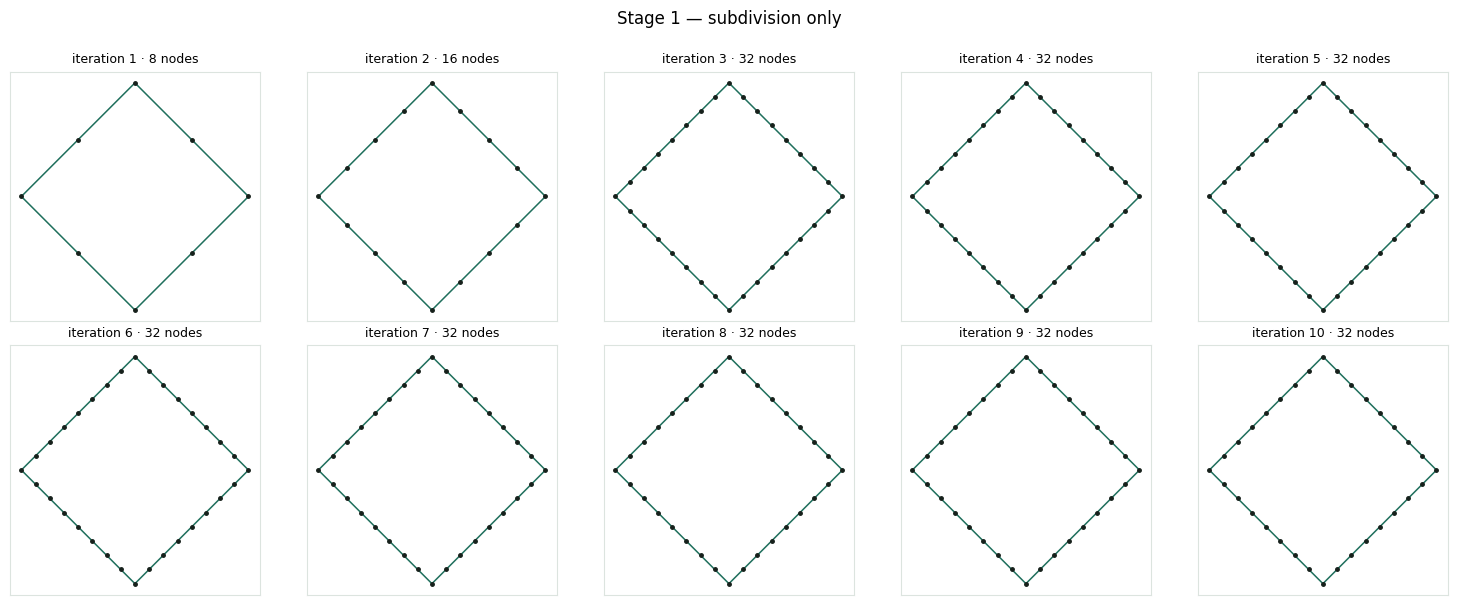

In [ ]:
stage1 = run_simulation(with_weights())
print("node counts:", [len(s) for s in stage1])
print("PASS" if [len(s) for s in stage1][:5] == [4, 8, 16, 32, 32] else "FAIL — subdivision is wrong")
draw_grid(stage1, "Stage 1 — subdivision only")
plt.show()

**The loop densifies and then freezes**, and the shape never changes at all — it is the same
diamond in every panel, only more finely divided. A midpoint of a straight edge lies *on* that
edge, so subdivision adds nodes without moving the curve.

This is correct. Subdivision alone cannot sustain growth, because nothing stretches the edges back
past the threshold. Subdivision supplies material; it does not create shape.

## 9 · Stage 2 — with repulsion

Nodes now push apart. Edges stretch back past `maxDistance`, subdivision fires again, and the
feedback loop closes.

node counts: [4, 8, 16, 32, 32, 40, 40, 40, 40, 48, 48]


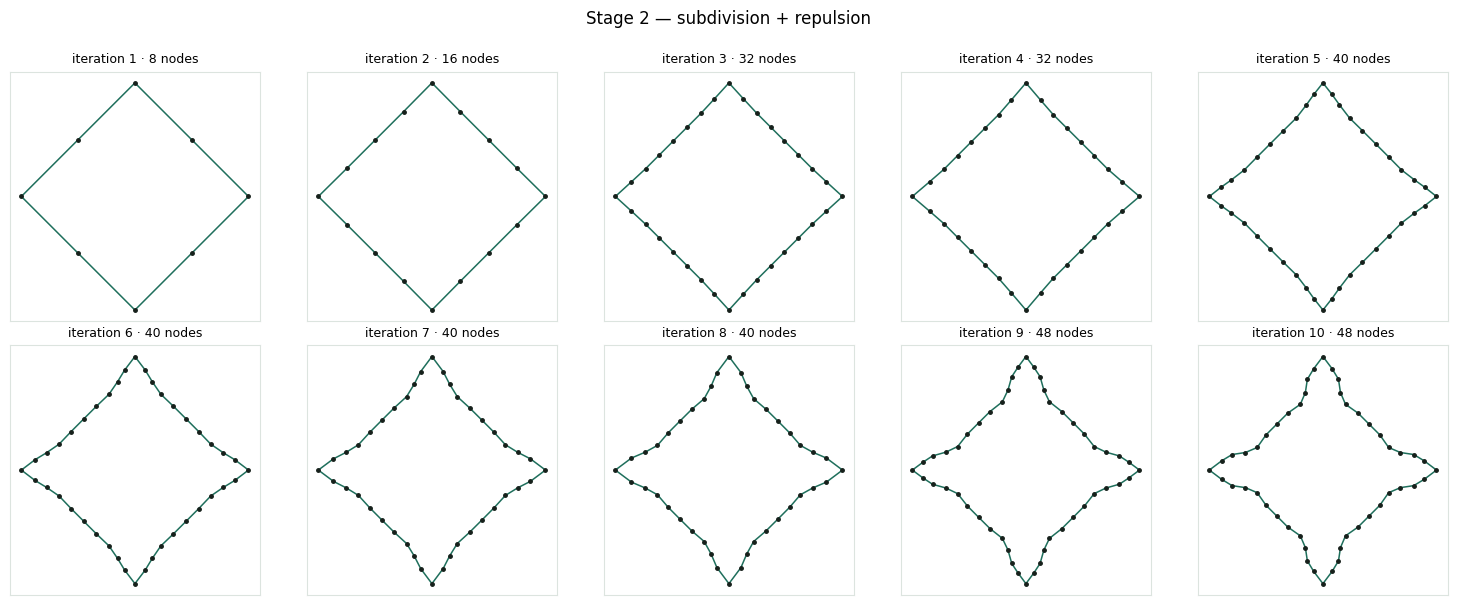

In [ ]:
stage2 = run_simulation(with_weights(repulsion=1.0))
print("node counts:", [len(s) for s in stage2])
draw_grid(stage2, "Stage 2 — subdivision + repulsion")
plt.show()

Node count now climbs past 32 instead of freezing. **This is the moment it becomes differential
growth** — and this alone is the complete algorithm as Kaspar formulates it.

## 10 · Stage 3 — with attraction

Attraction pulls each node toward its two connected neighbours, opposing repulsion and keeping the
loop from tearing apart.

node counts: [4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32]


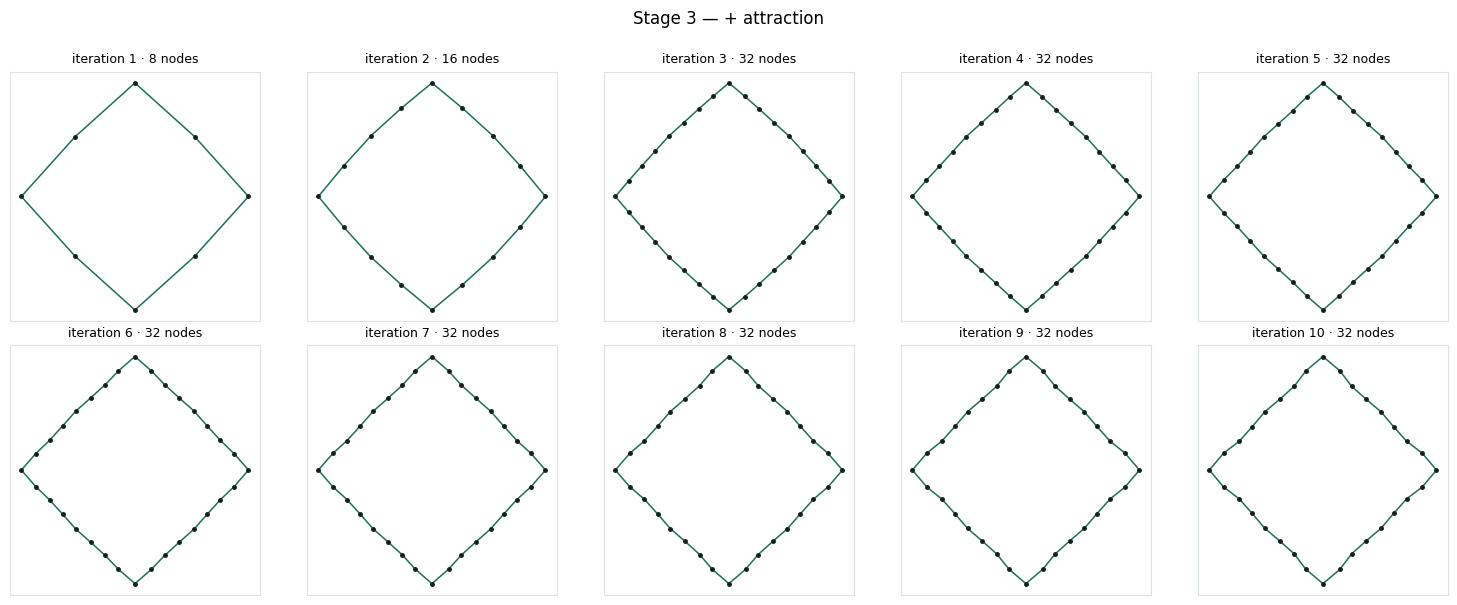

In [ ]:
stage3 = run_simulation(with_weights(repulsion=1.0, attraction=1.0))
print("node counts:", [len(s) for s in stage3])
draw_grid(stage3, "Stage 3 — + attraction")
plt.show()

Growth **stops**, and the node count holds at 32.

This is not a bug — it is the system reaching equilibrium. Attraction inward exactly balances
repulsion outward, and because a regular polygon under symmetric forces stays a regular polygon,
nothing ever breaks the tie. Attraction is necessary to keep the curve intact, but on a perfectly
symmetric starting shape it also freezes it.

## 11 · Stage 4 — with alignment

Alignment moves each node toward the midpoint of its neighbours — bending stiffness, resisting
sharp corners.

node counts: [4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32]


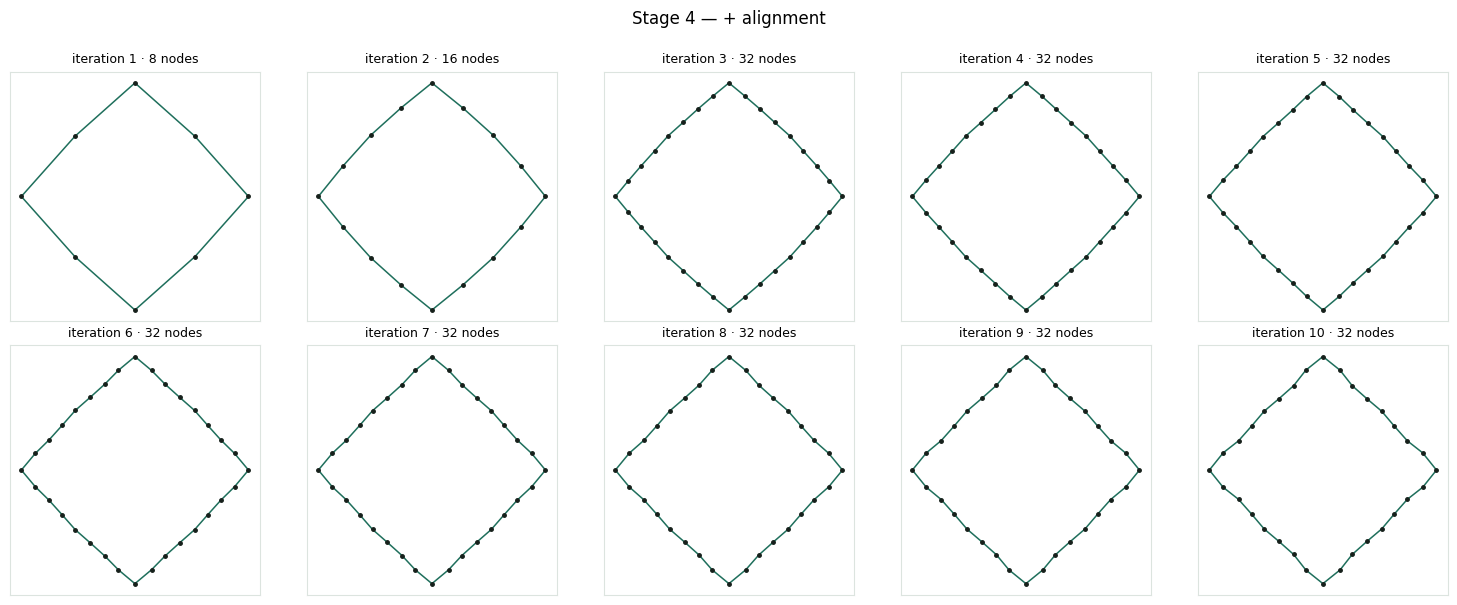

In [ ]:
stage4 = run_simulation(with_weights(repulsion=1.0, attraction=1.0, alignment=1.0))
print("node counts:", [len(s) for s in stage4])
draw_grid(stage4, "Stage 4 — + alignment")
plt.show()

Still frozen at 32. Alignment smooths the curve but is also a symmetric force, so it cannot break
the equilibrium either.

Note also that alignment and attraction push in the *same direction*: attraction gives
`F·((prev − p) + (next − p))` and alignment gives `A·((prev + next)/2 − p)`, which is the same
vector scaled by `A/2` instead of `F`. On this curve they differ only in magnitude.

## 12 · Stage 5 — with Brownian motion

The symmetry has to be broken by something. Random jitter is that something.

node counts: [4, 8, 16, 32, 32, 34, 33, 35, 37, 38, 42]


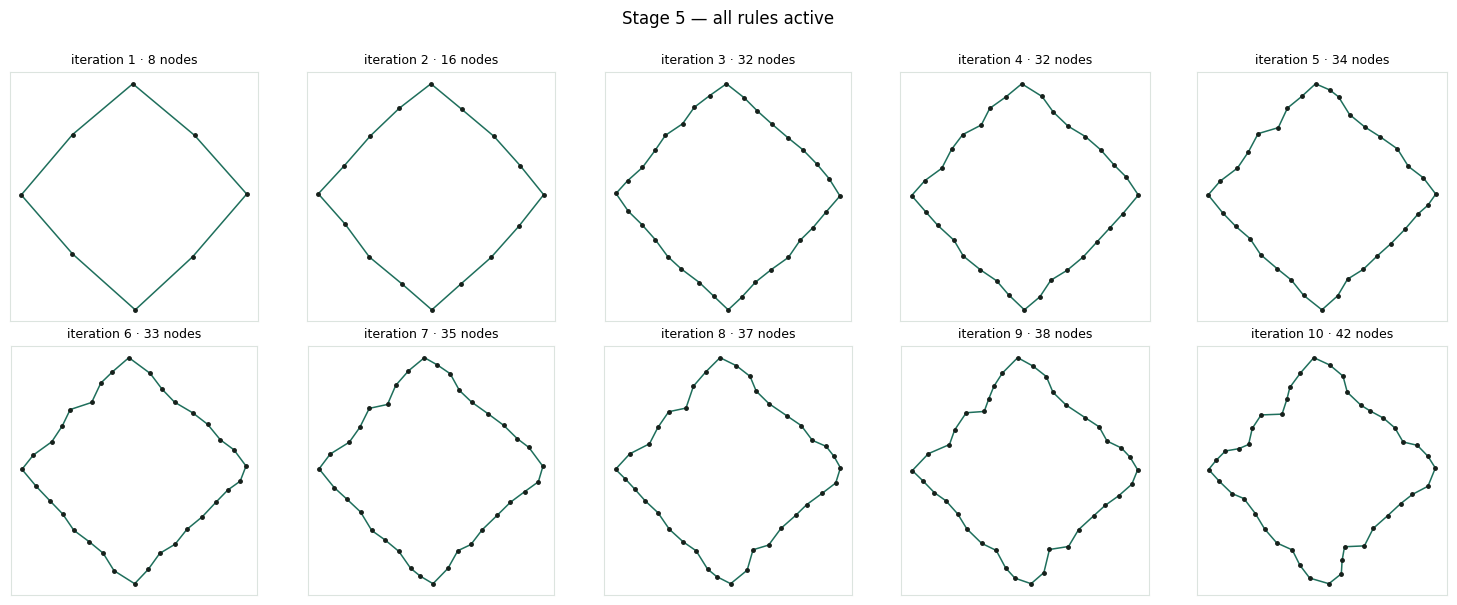

In [ ]:
stage5 = run_simulation(with_weights(repulsion=1.0, attraction=1.0,
                                     alignment=1.0, brownian=1.0))
print("node counts:", [len(s) for s in stage5])
draw_grid(stage5, "Stage 5 — all rules active")
plt.show()

Growth resumes. Once no two nodes feel exactly identical forces, one region gets slightly ahead,
its edges stretch further, it subdivides more, and the asymmetry compounds. **That runaway
feedback is differential growth.**

This is why Dr. Ferdousi's implementation includes Brownian motion, and why her run — starting
from two arbitrary points rather than a symmetric shape — grows without needing it as urgently.

## 13 · All five stages side by side

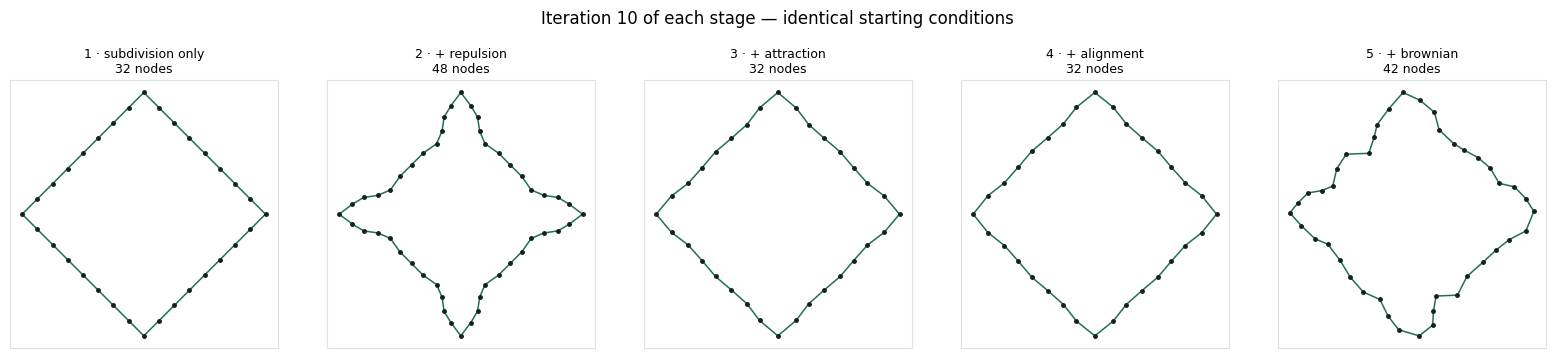

In [ ]:
runs = [("1 · subdivision only", stage1), ("2 · + repulsion", stage2),
        ("3 · + attraction", stage3), ("4 · + alignment", stage4),
        ("5 · + brownian", stage5)]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, (name, snaps) in zip(axes, runs):
    draw(snaps[-1], ax, f"{name}\n{len(snaps[-1])} nodes")
fig.suptitle("Iteration 10 of each stage — identical starting conditions", fontsize=12, y=1.04)
fig.tight_layout()
plt.show()

## 14 · A long run

Ten iterations shows the *mechanism*; the characteristic ruffled pattern needs hundreds. At low
iteration counts individual nodes and edges are still visible, which is what makes the earlier
figures readable — but this is what the algorithm is actually for.

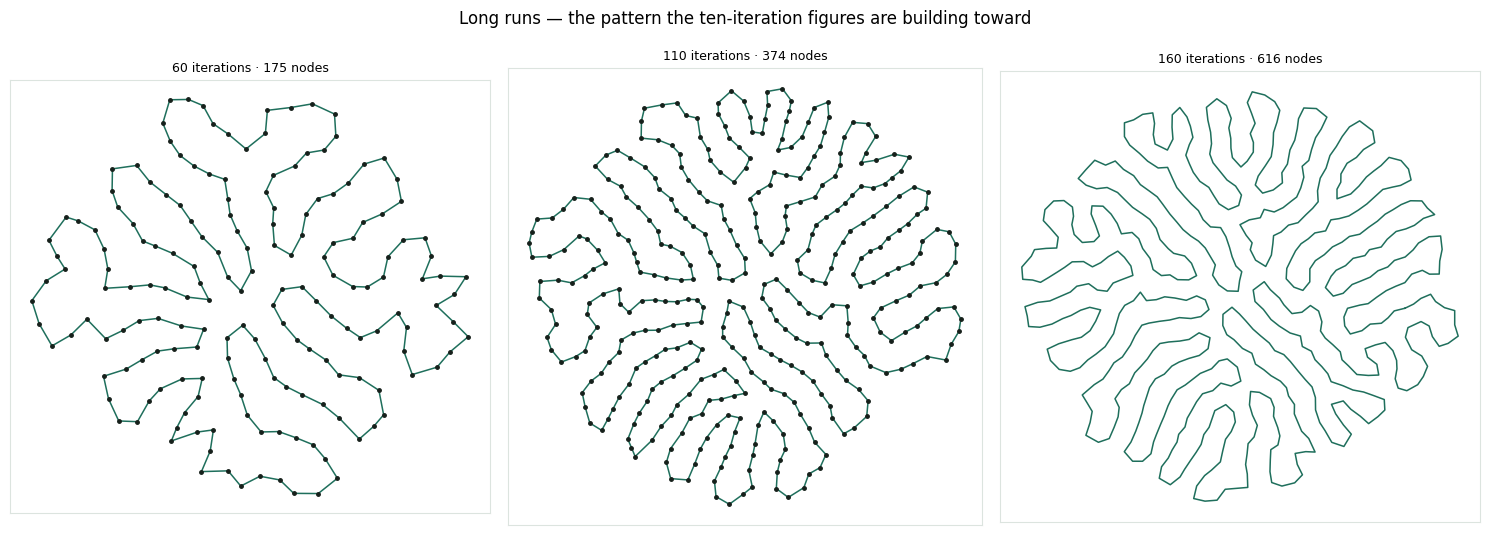

In [ ]:
long_params = with_weights(repulsion=1.0, attraction=1.0, alignment=1.0, brownian=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, n in zip(axes, (60, 110, 160)):
    snaps = run_simulation(long_params, n_iterations=n)
    draw(snaps[-1], ax, f"{n} iterations · {len(snaps[-1])} nodes",
         show_nodes=len(snaps[-1]) <= 400)
fig.suptitle("Long runs — the pattern the ten-iteration figures are building toward", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## 15 · Observations

**Subdivision supplies material, not shape.** Stage 1 changes the node count and nothing else. The
curve is geometrically identical in all ten panels.

**Repulsion is what makes it grow.** Stage 2 is the first stage where node count does not
plateau, and it is the complete algorithm in Kaspar's minimal formulation.

**Attraction and alignment stabilise but do not drive.** Both are symmetric, so on a symmetric
starting shape they hold the system at equilibrium. They matter for the *quality* of the folds,
not for whether folds appear.

**Symmetry has to be broken.** Stage 5 is where growth resumes. This is the clearest result in the
notebook: three of the four forces do nothing to escape a symmetric equilibrium, and the smallest
random perturbation does.

**On performance.** `applyRepulsion` compares every node against every other, which is O(N²).
That is fine to roughly 1,000 nodes and slow beyond it. Webb solves this with an R-tree spatial
index; the Python equivalent is `scipy.spatial.cKDTree`, and Dr. Ferdousi's unused `Grid` class
was the beginning of the same idea. Not needed at this scale.
